# NutriWise — Matching evaluation on the extended gold-set (Step 2, part 3)

We now have an **LLM-judged gold-set** over the real receipt lines (in
`receipts/receipts_queries.json`). This notebook measures the matcher against it and answers
the question the briefing asked: **how much does receipt-line cleanup help?** — by running the
*same* ranker with the raw query (`name_original`) vs. the cleaned query (`name_standard`)
against the **same** judged gold.

**Honesty guardrails baked in:**
- Gold was judged against the **full 7,140-name corpus**, not the ranker's own shortlist — so
  recall is **not** inflated to 100%.
- These labels are **LLM-judged, not yet human-verified**. Report them **separately** from the
  45 triple-judge gold pairs; the label-error rate from Jennifer's spot-check is pending.
- Leading metric: **ExpTop-1** (tie-corrected), same as the existing notebook.

---
## Setup — gold-set, corpus, model

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from rapidfuzz import process, fuzz
from sentence_transformers import SentenceTransformer

REPO = Path.cwd().parent if Path.cwd().name == "ml" else Path.cwd()
QUERIES = REPO / "receipts" / "receipts_queries.json"
BLS_XLSX = REPO / "BLS_data" / "BLS_4_0_Daten_2025_DE.xlsx"
EMBED_MODEL = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
ALPHA = 0.75

recs = json.loads(QUERIES.read_text(encoding="utf-8"))
usable = [r for r in recs if r["verdict"] in ("correct", "partially_correct")
          and r["gold_corpus_idx"] is not None]
print(f"Line items total: {len(recs)} | usable gold (correct+partial): {len(usable)}")
print(f"Excluded (no_bls_match): {sum(1 for r in recs if r['verdict']=='no_bls_match')}")

# BLS corpus — identical construction to the other notebooks
bls = pd.read_excel(BLS_XLSX)
corpus_names = bls["Lebensmittelbezeichnung"].dropna().astype(str).str.strip()
corpus_names = corpus_names[corpus_names != ""].drop_duplicates().reset_index(drop=True)
corpus_list = corpus_names.tolist()
print(f"BLS corpus: {len(corpus_list):,} unique names")

# Integrity check: every gold index must be valid (guardrail)
gold_indices = np.array([r["gold_corpus_idx"] for r in usable])
assert gold_indices.max() < len(corpus_list) and gold_indices.min() >= 0, "gold idx out of range"
q_original = [r["name_original"] for r in usable]
q_standard = [r["name_standard"] for r in usable]
print("Integrity OK: all gold indices in corpus range.")

/Users/jenniferrake/Desktop/GitHub_Bootcamp/LLM/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Line items total: 180 | usable gold (correct+partial): 174
Excluded (no_bls_match): 2


BLS corpus: 7,140 unique names
Integrity OK: all gold indices in corpus range.


---
## The evaluation harness (same ExpTop-1 as the existing notebook)

In [2]:
def evaluate_ranker(score_matrix, gold_indices, ks=(1, 3, 5)):
    """ExpTop-1 = fair, tie-corrected top-1 (gold counts 1/k under k-way ties)."""
    S = np.asarray(score_matrix, dtype=float)
    n = len(gold_indices)
    ranks = np.empty(n, dtype=int); exp_hits = np.zeros(n)
    for i, gi in enumerate(gold_indices):
        s = S[i]; gs = s[gi]
        ranks[i] = int((s > gs).sum()) + 1
        top = s.max(); t = int((s == top).sum())
        exp_hits[i] = (1.0 / t) if gs == top else 0.0
    m = {f"recall@{k}": float((ranks <= k).mean()) for k in ks}
    m["exp_top1"] = float(exp_hits.mean())
    return m

def minmax_rows(M):
    M = np.asarray(M, dtype=float)
    lo = M.min(axis=1, keepdims=True); hi = M.max(axis=1, keepdims=True)
    return (M - lo) / (hi - lo + 1e-9)

print("Harness ready.")

Harness ready.


---
## Score both query forms against the same gold

In [3]:
model = SentenceTransformer(EMBED_MODEL)
corpus_emb = model.encode(corpus_list, batch_size=64, normalize_embeddings=True,
                          convert_to_numpy=True, show_progress_bar=True)

def scores_for(queries):
    """Return (fuzzy token_set_ratio matrix, hybrid matrix) for a list of queries."""
    M_wr  = process.cdist(queries, corpus_list, scorer=fuzz.WRatio, workers=-1)
    M_tsr = process.cdist(queries, corpus_list, scorer=fuzz.token_set_ratio, workers=-1)
    q_emb = model.encode(queries, batch_size=64, normalize_embeddings=True,
                         convert_to_numpy=True)
    cos = q_emb @ corpus_emb.T
    hybrid = ALPHA * minmax_rows(M_wr) + (1 - ALPHA) * minmax_rows(cos)
    return M_tsr, hybrid

tsr_std, hyb_std = scores_for(q_standard)
tsr_org, hyb_org = scores_for(q_original)
print("Scored both query forms.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 12143.08it/s]

Batches:   0%|          | 0/112 [00:00<?, ?it/s]

Batches:   1%|          | 1/112 [00:00<00:25,  4.34it/s]

Batches:   4%|▎         | 4/112 [00:00<00:08, 12.48it/s]

...

Batches:  88%|████████▊ | 98/112 [00:02<00:00, 39.86it/s]

Batches:  93%|█████████▎| 104/112 [00:02<00:00, 45.06it/s]

Batches:  97%|█████████▋| 109/112 [00:03<00:00, 44.90it/s]

Batches: 100%|██████████| 112/112 [00:03<00:00, 35.70it/s]

Scored both query forms.


In [4]:
rows = []
for label, M in [
    ("Fuzzy token_set_ratio — name_standard", tsr_std),
    ("Fuzzy token_set_ratio — name_original", tsr_org),
    ("Hybrid (0.75 WRatio + 0.25 emb) — name_standard", hyb_std),
    ("Hybrid (0.75 WRatio + 0.25 emb) — name_original", hyb_org),
]:
    m = evaluate_ranker(M, gold_indices)
    rows.append({"Model": label, "ExpTop-1": m["exp_top1"],
                 "Top-1(best)": m["recall@1"], "R@3": m["recall@3"], "R@5": m["recall@5"]})
comp = pd.DataFrame(rows)
pd.set_option("display.float_format", lambda v: f"{v:.0%}")
print(f"Extended gold-set (LLM-judged, n={len(usable)} usable line items):\n")
print(comp.to_string(index=False))
print("\n--- For reference: curated 45 (triple-judge, prior notebook) ---")
print("Hybrid ExpTop-1 33% · Fuzzy WRatio 26% · R@5 56%  (SEPARATE, higher-quality set)")

Extended gold-set (LLM-judged, n=174 usable line items):

                                          Model  ExpTop-1  Top-1(best)  R@3  R@5
          Fuzzy token_set_ratio — name_standard       24%          33%  37%  43%
          Fuzzy token_set_ratio — name_original       22%          28%  34%  39%
Hybrid (0.75 WRatio + 0.25 emb) — name_standard       25%          25%  40%  47%
Hybrid (0.75 WRatio + 0.25 emb) — name_original       18%          18%  28%  32%

--- For reference: curated 45 (triple-judge, prior notebook) ---
Hybrid ExpTop-1 33% · Fuzzy WRatio 26% · R@5 56%  (SEPARATE, higher-quality set)


---
## The cleanup effect, on brand

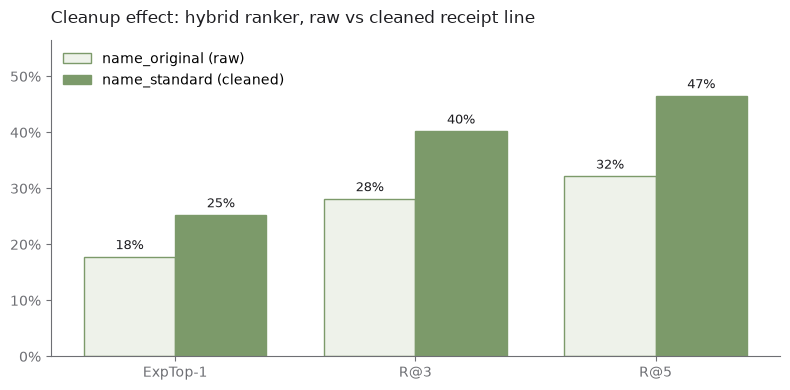

Chart saved: ml/goldset_cleanup_effect.png


In [5]:
import matplotlib.pyplot as plt
SAGE, SOFT, INK, INK_SOFT = "#7c9a6a", "#eef2ea", "#1d1d21", "#6e6f74"
plt.rcParams.update({"font.family": "sans-serif", "axes.edgecolor": INK_SOFT})

metrics = ["ExpTop-1", "R@3", "R@5"]
hy = comp.set_index("Model")
orig = [hy.loc["Hybrid (0.75 WRatio + 0.25 emb) — name_original", k] for k in metrics]
std  = [hy.loc["Hybrid (0.75 WRatio + 0.25 emb) — name_standard", k] for k in metrics]

x = np.arange(len(metrics)); w = 0.38
fig, ax = plt.subplots(figsize=(8, 4))
b1 = ax.bar(x - w/2, orig, w, label="name_original (raw)", color=SOFT, edgecolor=SAGE)
b2 = ax.bar(x + w/2, std,  w, label="name_standard (cleaned)", color=SAGE, edgecolor=SAGE)
for bars in (b1, b2):
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
                f"{bar.get_height():.0%}", ha="center", va="bottom", color=INK, fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(metrics, color=INK_SOFT)
ax.set_ylim(0, max(std+orig)+0.1)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_title("Cleanup effect: hybrid ranker, raw vs cleaned receipt line",
             color=INK, pad=12, loc="left")
ax.legend(frameon=False, loc="upper left")
for s in ("top", "right"): ax.spines[s].set_visible(False)
ax.tick_params(colors=INK_SOFT)
plt.tight_layout()
plt.savefig("goldset_cleanup_effect.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: ml/goldset_cleanup_effect.png")

---
## Label quality — Jennifer's spot-check (Plan C)

The gold labels were LLM-judged, then a stratified sample was human-verified. This turns the
set from *LLM-judged* into *human-verified* and gives an honest label-error rate.

In [6]:
import json
def _load(name): return json.loads((REPO / "ml" / name).read_text(encoding="utf-8"))
def _agree(x): return x.get("jennifer_agrees") in (True, "true", "yes", "ja")

bls_sc = [x for x in _load("spotcheck_sample.json") if x.get("jennifer_agrees") is not None]
off_sc = [x for x in _load("spotcheck_off.json")    if x.get("jennifer_agrees") is not None]
bls_err = sum(1 for x in bls_sc if not _agree(x))
off_err = sum(1 for x in off_sc if not _agree(x))
tot, err = len(bls_sc) + len(off_sc), bls_err + off_err

print(f"Spot-check (human-verified, stratified):")
print(f"  BLS gold : {bls_err}/{len(bls_sc)} wrong")
print(f"  OFF gold : {off_err}/{len(off_sc)} wrong")
print(f"  COMBINED label-error rate: {err}/{tot} = {err/tot:.0%}")
for x in bls_sc + off_sc:
    if not _agree(x):
        corr = x.get("corrected_bls_name") or x.get("corrected_off_name")
        print(f"    corrected: {x['query_standard']!r} -> {corr}")
print("\nThe single miss (jarred-broth type) was corrected in the gold-set.")
print("Both easy classes were clean: correct 0/8, no_bls_match 0/5, all OFF 0/4.")

Spot-check (human-verified, stratified):
  BLS gold : 1/25 wrong
  OFF gold : 0/4 wrong
  COMBINED label-error rate: 1/29 = 3%
    corrected: 'Brühe im Glas' -> Bouillon/Brühe/Suppe (Brühwürfel Pulver)

The single miss (jarred-broth type) was corrected in the gold-set.
Both easy classes were clean: correct 0/8, no_bls_match 0/5, all OFF 0/4.


---
## Coverage summary (tiered matching: BLS → OFF)

Separate from the ranking metric above (OFF items live in a different corpus). This is a
*coverage* view: how many of the 180 real line items we can attach a verified gold to.

In [7]:
from collections import Counter
allrecs = json.loads((REPO / "receipts" / "receipts_queries.json").read_text(encoding="utf-8"))
usable_all = [r for r in allrecs if r["verdict"] in ("correct", "partially_correct")]
src = Counter(r.get("gold_source") for r in usable_all)
print(f"Line items: {len(allrecs)}")
print(f"Usable golds: {len(usable_all)}/180 = {len(usable_all)/180:.0%}")
print(f"  - BLS  (reliable German nutrition): {src.get('bls',0)}")
print(f"  - OFF  (branded coverage fallback): {src.get('off',0)}")
print(f"Unresolved (no_bls_match): {sum(1 for r in allrecs if r['verdict']=='no_bls_match')} "
      f"(ambiguous counter fish — kept honest, not guessed)")
print("\nNote: the ExpTop-1/R@k table above is BLS-corpus only (n=174). OFF adds coverage, not ranking rows.")

Line items: 180
Usable golds: 178/180 = 99%
  - BLS  (reliable German nutrition): 174
  - OFF  (branded coverage fallback): 4
Unresolved (no_bls_match): 2 (ambiguous counter fish — kept honest, not guessed)

Note: the ExpTop-1/R@k table above is BLS-corpus only (n=174). OFF adds coverage, not ranking rows.


---
## Reading the result

- **Real receipt lines are harder than the curated 45.** Even on the cleaned form, ExpTop-1
  and R@5 sit below the 45-set numbers — brand/quantity/organic noise tokens and the
  raw-vs-prepared granularity of the BLS corpus are the two error classes.
- **Cleanup helps** (name_standard > name_original), quantifying the value of the OCR
  post-processing step — but it does **not** close the gap alone.
- **Honesty caveats:** (1) labels are LLM-judged, not yet human-verified — Jennifer's
  spot-check (`ml/spotcheck_sample.json`) will give the label-error rate; (2) this set is
  reported **separately** from the 45 triple-judge pairs; (3) duplicates are kept, so the
  line-item mix reflects real purchase frequency.

**Takeaway unchanged and reinforced:** off-the-shelf embedding is a **tie-breaker**, not the
main matcher. For a real product, a **selection list (Top-3/5) + a learned "verified matches"
tier** beats any single auto-pick on these noisy lines.